# Intraday Bias Analysis on EUR/USD (H1)

This notebook explores the existence of intraday seasonality in the EUR/USD FX market using hourly data from 2018 onward.

The main objective is to identify whether specific time windows exhibit persistent directional bias that could potentially be exploited in a systematic trading strategy.

The analysis is conducted on the in-sample period only, while the most recent year is reserved for out-of-sample validation in later stages of the research pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Loading

We start by loading the EUR/USD hourly dataset and preparing the time index for time-series analysis.

In [2]:
# Load EURUSD H1 dataset
df_full = pd.read_csv("../data/eurusd_h1.csv")

# Convert timestamp column to datetime format
df_full["time"] = pd.to_datetime(df_full["time"])

# Set datetime as index for time-series operations
df_full = df_full.set_index("time")

## In-Sample / Out-of-Sample Split

To reduce the risk of overfitting bias, the dataset is divided into:

- **In-sample period**: used for exploratory analysis and strategy development
- **Out-of-sample period**: reserved for later validation

The final year of available data is excluded from the research phase and kept untouched during signal discovery.

In [3]:
split_date = "2024-01-01"

df = df_full[df_full.index < split_date].copy()

## Return Construction

Hourly returns are computed using close-to-close variation.
Therefore, the return associated with hour h represents the price movement from the previous H1 close to the current H1 close.

Additionally, the hour of the day is extracted from the timestamp index in order to analyze intraday seasonal effects.

In [5]:
# Construct discrete returns from close prices.
# The first value is set to 0 to maintain alignment in time-series operations.
df["returns"]=df["close"].pct_change().fillna(0)

# Extract hour of day from datetime index
df["hour"] = df.index.hour

In [6]:
# Quick sanity check of the dataset structure

display(df)

df.info()

,open,high,low,close,returns,hour
time,,,,,,
2018-04-06 08:00:00,1.22383,1.22424,1.22355,1.22374,0.000000,8
2018-04-06 09:00:00,1.22374,1.22393,1.22275,1.22357,-0.000139,9
2018-04-06 10:00:00,1.22356,1.22367,1.22149,1.22270,-0.000711,10
2018-04-06 11:00:00,1.22270,1.22369,1.22217,1.22350,0.000654,11
2018-04-06 12:00:00,1.22350,1.22476,1.22346,1.22430,0.000654,12
...,...,...,...,...,...,...
2023-12-29 19:00:00,1.10608,1.10669,1.10527,1.10640,0.000289,19
2023-12-29 20:00:00,1.10640,1.10641,1.10490,1.10531,-0.000985,20
2023-12-29 21:00:00,1.10531,1.10541,1.10378,1.10407,-0.001122,21


<class 'pandas.DataFrame'>
DatetimeIndex: 35654 entries, 2018-04-06 08:00:00 to 2023-12-29 23:00:00
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   open     35654 non-null  float64
 1   high     35654 non-null  float64
 2   low      35654 non-null  float64
 3   close    35654 non-null  float64
 4   returns  35654 non-null  float64
 5   hour     35654 non-null  int32  
dtypes: float64(5), int32(1)
memory usage: 1.8 MB


## Rolling Window Stability Analysis

Intraday effects in financial markets are often regime-dependent and may decay over time.

To evaluate the robustness of the detected seasonal patterns, the analysis is repeated across multiple rolling windows:

- Last 3 years
- Last 2 years
- Last 1 year

This allows us to assess whether the observed intraday bias is stable or merely concentrated in a specific historical regime.

In [4]:
# Anchor point = latest available timestamp
end_time = df.index.max()

# Rolling time windows (clean and explicit)
df_1y = df.loc[end_time - pd.Timedelta(days=365):]
df_2y = df.loc[end_time - pd.Timedelta(days=730):]
df_3y = df.loc[end_time - pd.Timedelta(days=1095):]

In [5]:
# Quick sanity check: verify that rolling windows roughly match expected sizes

print("\nTime spans:")
print("1Y:", df_1y.index.min(), "->", df_1y.index.max())
print("2Y:", df_2y.index.min(), "->", df_2y.index.max())
print("3Y:", df_3y.index.min(), "->", df_3y.index.max())


Time spans:
1Y: 2022-12-29 23:00:00 -> 2023-12-29 23:00:00
2Y: 2021-12-29 23:00:00 -> 2023-12-29 23:00:00
3Y: 2020-12-29 23:00:00 -> 2023-12-29 23:00:00


In [9]:
# Average hourly returns over the full sample.
# Cumulated to highlight intraday directional patterns.
avg_full_returns = df.groupby("hour")["returns"].mean()
avg_full_curve = (1 + avg_full_returns).cumprod() - 1


# Repeat the analysis on the last 3 years of data
# to evaluate the stability of the intraday bias over time.
avg_3y_returns = df_3y.groupby("hour")["returns"].mean()
avg_3y_curve = (1 + avg_3y_returns).cumprod() - 1


# Repeat the analysis on the last 2 years.
avg_2y_returns = df_2y.groupby("hour")["returns"].mean()
avg_2y_curve = (1 + avg_2y_returns).cumprod() - 1


# Repeat the analysis on the last year.
avg_1y_returns = df_1y.groupby("hour")["returns"].mean()
avg_1y_curve = (1 + avg_1y_returns).cumprod() - 1

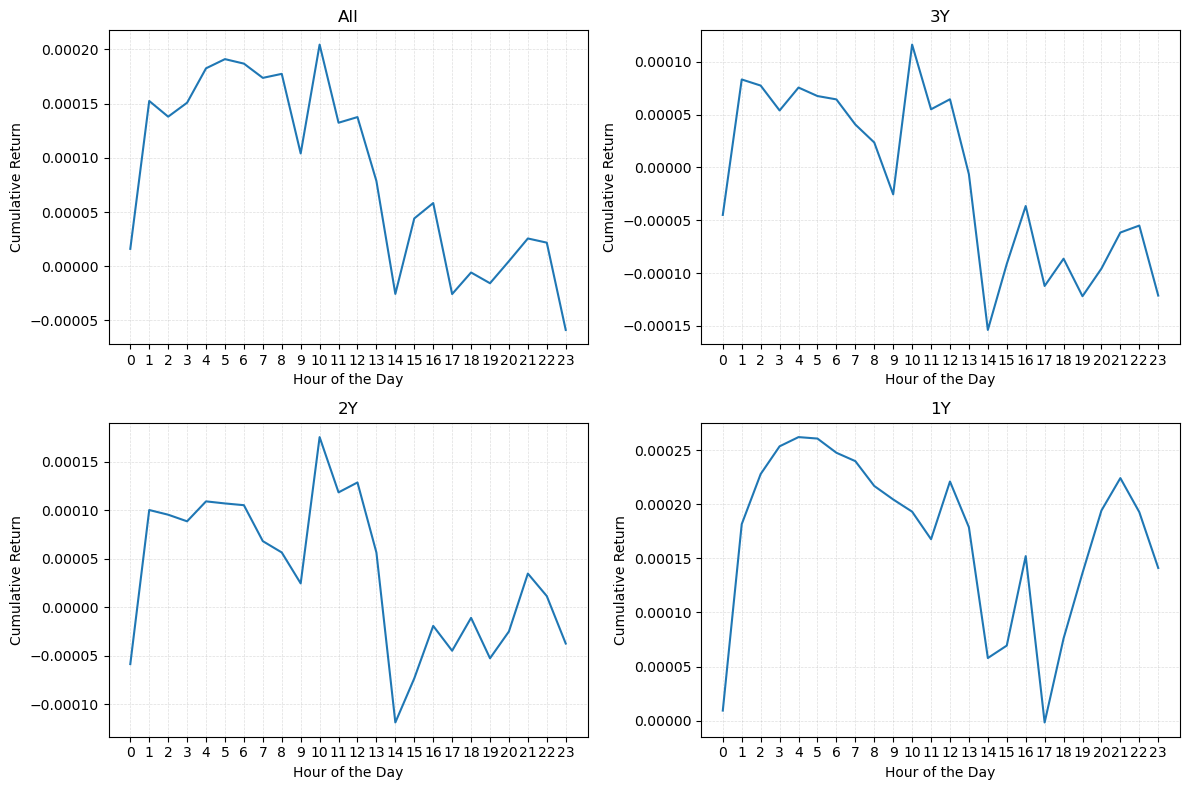

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(12,8))

axs[0,0].plot(avg_full_curve); axs[0,0].set_title("All")
axs[0,1].plot(avg_3y_curve); axs[0,1].set_title("3Y")
axs[1,0].plot(avg_2y_curve); axs[1,0].set_title("2Y")
axs[1,1].plot(avg_1y_curve); axs[1,1].set_title("1Y")

# Improve grid style
for ax in axs.flat:
    ax.set_xticks(range(0, 24, 1))  # grid every hour
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, alpha=0.25, color="gray")
    ax.set_xlabel("Hour of the Day")
    ax.set_ylabel("Cumulative Return")

plt.tight_layout()
plt.show()

## Preliminary Observations

Several interesting patterns are visible in the intraday cumulative return curves.

Directional tendencies can be observed in certain time intervals and appear, to some extent, across multiple rolling windows and sample splits.

However, at this stage no conclusions regarding tradability should be made.

The next step of the research process will consist of systematically testing all possible entry/exit hour combinations through a fully vectorized backtesting framework.